In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

<h3> Effect of DFT+U in Zinc Oxide band gap correction <h3>

<div align="center">

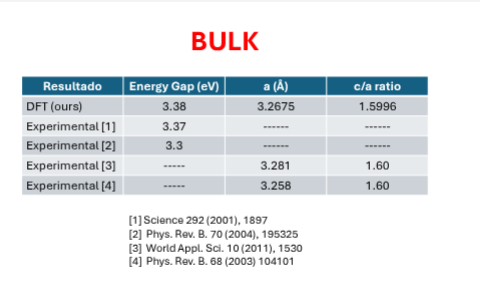

</div>

In [9]:
dados = pd.read_csv('bandgaps.dat', names=['file', 'band_gap'])
dados[['u_Zn', 'u_O']] = dados['file'].str.extract(r'ZnO_Hub_(\d+\.\d+)_(\d+\.\d+)').astype(float)
dados.to_csv('band_gap_DFT+U.csv', index=False)

In [10]:
dados

,file,band_gap,u_Zn,u_O
0,ZnO_Hub_4.00_4.00,1.9251,4.0,4.0
1,ZnO_Hub_4.50_4.00,1.9655,4.5,4.0
2,ZnO_Hub_5.00_4.00,2.0037,5.0,4.0
3,ZnO_Hub_4.00_4.50,2.0346,4.0,4.5
4,ZnO_Hub_5.50_4.00,2.0399,5.5,4.0
...,...,...,...,...
283,ZnO_Hub_10.00_12.00,4.3598,10.0,12.0
284,ZnO_Hub_10.50_12.00,4.3923,10.5,12.0
285,ZnO_Hub_11.00_12.00,4.4230,11.0,12.0
286,ZnO_Hub_11.50_12.00,4.4520,11.5,12.0


In [11]:
dados[ (dados['band_gap'] > 3.3) * (dados['band_gap'] < 3.4) ]

,file,band_gap,u_Zn,u_O
166,ZnO_Hub_4.00_10.00,3.3011,4.0,10.0
167,ZnO_Hub_6.50_9.00,3.3050,6.5,9.0
168,ZnO_Hub_10.50_8.00,3.3077,10.5,8.0
169,ZnO_Hub_8.50_8.50,3.3237,8.5,8.5
170,ZnO_Hub_11.00_8.00,3.3322,11.0,8.0
171,ZnO_Hub_5.50_9.50,3.3402,5.5,9.5
172,ZnO_Hub_7.00_9.00,3.3452,7.0,9.0
173,ZnO_Hub_9.00_8.50,3.3549,9.0,8.5
174,ZnO_Hub_11.50_8.00,3.3556,11.5,8.0
175,ZnO_Hub_4.50_10.00,3.3586,4.5,10.0


In [12]:
from scipy.interpolate import griddata

In [13]:
u_zn_unique = dados['u_Zn'].unique()
u_o_unique = dados['u_O'].unique()

print(f"Valores percorridos de U:\n{u_zn_unique}")

U_Zn, U_O = np.meshgrid(u_zn_unique, u_o_unique)
points = dados[['u_Zn', 'u_O']].values # 2D data points (288,2)
values = dados['band_gap'].values

# Cubic spline 
band_gap_grid = griddata(points=points, values=values, xi=(U_Zn, U_O), method='cubic')

print(f'{band_gap_grid.shape = }')

Valores percorridos de U:
[ 4.   4.5  5.   5.5  6.   6.5  7.   7.5  8.   8.5  9.   9.5 10.  10.5
 11.  11.5 12. ]
band_gap_grid.shape = (17, 17)


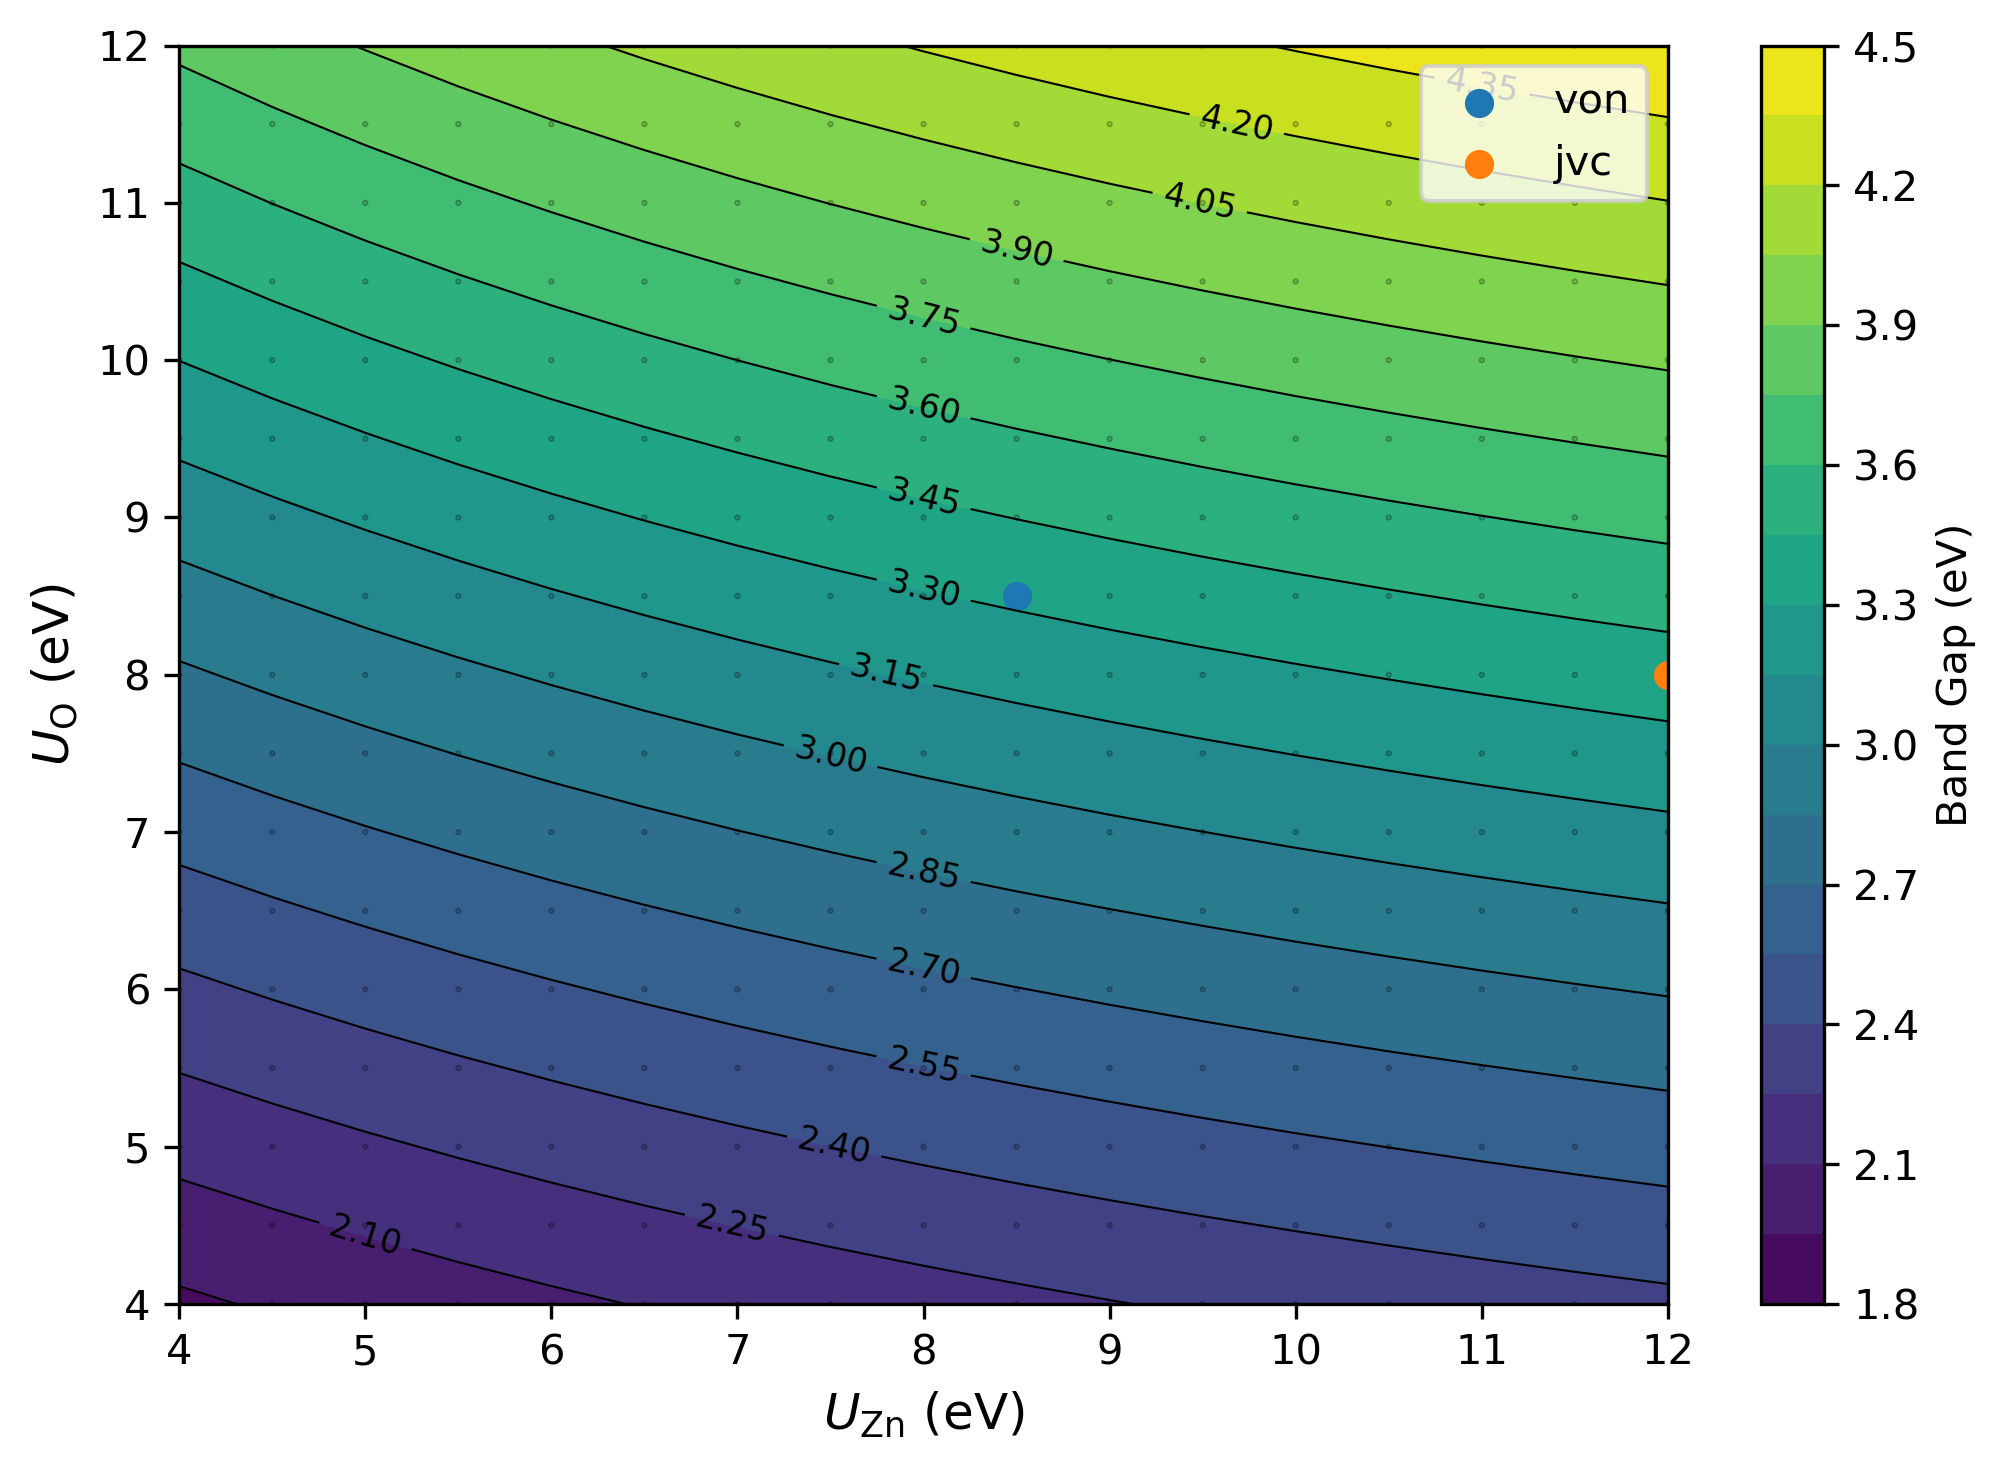

In [34]:
plt.figure(figsize=(7,5), dpi=300)
contour = plt.contourf(U_Zn, U_O, band_gap_grid, levels=20)
plt.colorbar(contour, label='Band Gap (eV)')

# Curvas de nível
contour_lines = plt.contour(U_Zn, U_O, band_gap_grid, levels=20, colors='black', linewidths=.5)
plt.clabel(contour_lines, inline=True, fontsize=8, fmt='%.2f')


# Configurações do gráfico
plt.xlabel('$U_{\\text{Zn}}$ (eV)', fontsize=12)
plt.ylabel('$U_{\\text{O}}$ (eV)', fontsize=12)



# Adicionar alguns pontos de dados para referência
plt.scatter(dados['u_Zn'], dados['u_O'], c=dados['band_gap'], cmap='viridis', 
          s=1, edgecolors='black', linewidth=0.5, alpha=0.3)

plt.scatter(x=8.5, y=8.5, label='von')
plt.scatter(x=12.0, y=8.0, label='jvc')
plt.tight_layout()
plt.legend()
plt.show()



(288, 2)